# Phase 1 : Importing Necessary Library

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot Style
sns.set_style("whitegrid")

# Phase 2 : Loading the Dataset

In [2]:
# Load the CSV file
df = pd.read_csv("Traffic Report Dataset.csv")

In [3]:
# Display first 5 rows
df.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [4]:
# Display 5 random records
df.sample(5, random_state=42)

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
142002,06/01/2018 03:30:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,SIDESWIPE SAME DIRECTION,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,15,6,6
132434,07/19/2018 11:43:00 AM,TRAFFIC SIGNAL,CLOUDY/OVERCAST,DAYLIGHT,REAR END,DIVIDED - W/MEDIAN (NOT RAISED),STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,11,5,7
106970,07/04/2024 10:40:00 AM,TRAFFIC SIGNAL,CLOUDY/OVERCAST,DAYLIGHT,PEDALCYCLIST,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,1.0,0.0,0.0,1.0,0.0,1.0,10,5,7
64659,10/13/2018 03:00:00 PM,NO CONTROLS,CLEAR,DAYLIGHT,ANGLE,ALLEY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,15,7,10
107577,07/18/2024 01:36:00 PM,NO CONTROLS,CLEAR,DAYLIGHT,PEDALCYCLIST,Y-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,INCAPACITATING INJURY,1.0,0.0,1.0,0.0,0.0,2.0,13,5,7


In [5]:
# Check Dataset Shape
# (number of rows and columns) 
df.shape

(209306, 24)

In [6]:
# Display Column Names
df.columns

Index(['crash_date', 'traffic_control_device', 'weather_condition',
       'lighting_condition', 'first_crash_type', 'trafficway_type',
       'alignment', 'roadway_surface_cond', 'road_defect', 'crash_type',
       'intersection_related_i', 'damage', 'prim_contributory_cause',
       'num_units', 'most_severe_injury', 'injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour',
       'crash_day_of_week', 'crash_month'],
      dtype='object')

In [7]:
# checking the datatypes 
df.dtypes

crash_date                        object
traffic_control_device            object
weather_condition                 object
lighting_condition                object
first_crash_type                  object
trafficway_type                   object
alignment                         object
roadway_surface_cond              object
road_defect                       object
crash_type                        object
intersection_related_i            object
damage                            object
prim_contributory_cause           object
num_units                          int64
most_severe_injury                object
injuries_total                   float64
injuries_fatal                   float64
injuries_incapacitating          float64
injuries_non_incapacitating      float64
injuries_reported_not_evident    float64
injuries_no_indication           float64
crash_hour                         int64
crash_day_of_week                  int64
crash_month                        int64
dtype: object

In [8]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209306 non-null  object 
 1   traffic_control_device         209306 non-null  object 
 2   weather_condition              209306 non-null  object 
 3   lighting_condition             209306 non-null  object 
 4   first_crash_type               209306 non-null  object 
 5   trafficway_type                209306 non-null  object 
 6   alignment                      209306 non-null  object 
 7   roadway_surface_cond           209306 non-null  object 
 8   road_defect                    209306 non-null  object 
 9   crash_type                     209306 non-null  object 
 10  intersection_related_i         209306 non-null  object 
 11  damage                         209306 non-null  object 
 12  prim_contributory_cause       

In [9]:
# Statistical Summary
df.describe()

,num_units,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
count,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000
mean,2.063300,0.382717,0.001859,0.038102,0.221241,0.121516,2.244002,13.373047,4.144024,6.771822
std,0.396012,0.799720,0.047502,0.233964,0.614960,0.450865,1.241175,5.603830,1.966864,3.427593
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,9.000000,2.000000,4.000000
50%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,14.000000,4.000000,7.000000
75%,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,17.000000,6.000000,10.000000
max,11.000000,21.000000,3.000000,7.000000,21.000000,15.000000,49.000000,23.000000,7.000000,12.000000


In [10]:
# Statistical Summary for Categorical Columns
df.describe(include='object')

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,intersection_related_i,damage,prim_contributory_cause,most_severe_injury
count,209306,209306,209306,209306,209306,209306,209306,209306,209306,209306,209306,209306,209306,209306
unique,189087,19,12,6,18,20,6,7,7,2,2,3,40,5
top,12/29/2020 05:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,Y,"OVER $1,500",UNABLE TO DETERMINE,NO INDICATION OF INJURY
freq,10,123944,164700,134109,64157,77753,204590,155905,171730,117376,199324,147313,58316,154789


# Phase 3 : Data Cleaning 

In [11]:
# Check Missing Values
df.isnull().sum()

crash_date                       0
traffic_control_device           0
weather_condition                0
lighting_condition               0
first_crash_type                 0
trafficway_type                  0
alignment                        0
roadway_surface_cond             0
road_defect                      0
crash_type                       0
intersection_related_i           0
damage                           0
prim_contributory_cause          0
num_units                        0
most_severe_injury               0
injuries_total                   0
injuries_fatal                   0
injuries_incapacitating          0
injuries_non_incapacitating      0
injuries_reported_not_evident    0
injuries_no_indication           0
crash_hour                       0
crash_day_of_week                0
crash_month                      0
dtype: int64

In [12]:
# Duplicate Records
df.duplicated().sum()

np.int64(31)

In [13]:
# Number of unique values in every column
df.nunique().sort_values()

crash_type                            2
intersection_related_i                2
damage                                3
injuries_fatal                        4
most_severe_injury                    5
lighting_condition                    6
alignment                             6
roadway_surface_cond                  7
road_defect                           7
crash_day_of_week                     7
injuries_incapacitating               8
num_units                            11
crash_month                          12
weather_condition                    12
injuries_reported_not_evident        13
first_crash_type                     18
injuries_total                       19
traffic_control_device               19
injuries_non_incapacitating          19
trafficway_type                      20
crash_hour                           24
injuries_no_indication               39
prim_contributory_cause              40
crash_date                       189087
dtype: int64

Phase 3 : Data Cleaning 

In [14]:
# chceking missing value 
df.isnull().sum()

crash_date                       0
traffic_control_device           0
weather_condition                0
lighting_condition               0
first_crash_type                 0
trafficway_type                  0
alignment                        0
roadway_surface_cond             0
road_defect                      0
crash_type                       0
intersection_related_i           0
damage                           0
prim_contributory_cause          0
num_units                        0
most_severe_injury               0
injuries_total                   0
injuries_fatal                   0
injuries_incapacitating          0
injuries_non_incapacitating      0
injuries_reported_not_evident    0
injuries_no_indication           0
crash_hour                       0
crash_day_of_week                0
crash_month                      0
dtype: int64

All columns = 0 Missing Values
Conclusion

There are no missing values in the dataset.

So, we don't need to perform any imputation (no mean, median, mode, or row deletion).


In [15]:
# checking dupliactes 
df.duplicated().sum()

np.int64(31)

There are 31 duplicate rows.

Duplicate records can bias the analysis because the same accident is counted multiple times.

( Duplicate records can introduce bias because the same observation is counted multiple times. This can affect exploratory analysis and model training, so I removed all duplicate rows before proceeding.)

In [16]:
# Remove Duplicates

df.drop_duplicates(inplace=True)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
# checking data types shape ( after removing duplicate records ) 
df.shape 

(209275, 24)

# Phase 4: Exploratory Data Analysis (EDA)      

Exploratory Data Analysis (EDA) is the process of understanding the dataset by using summary statistics and visualizations. It helps identify patterns, trends, relationships, anomalies, and insights before building machine learning models."

Target Variable Distribution

Before analyzing features, we should first understand what we are trying to predict.

In this project, we'll use:

crash_type

as our target variable.

In [19]:
# Target Variable Distribution 
df["crash_type"].value_counts()

crash_type
NO INJURY / DRIVE AWAY              117356
INJURY AND / OR TOW DUE TO CRASH     91919
Name: count, dtype: int64

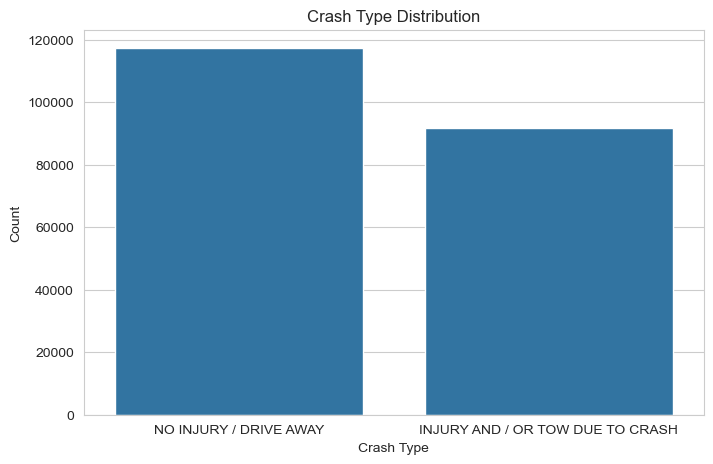

In [20]:
# Visualization
plt.figure(figsize=(8,5))

sns.countplot(x="crash_type", data=df)

plt.title("Crash Type Distribution")
plt.xlabel("Crash Type")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

In [21]:
# Weather Condition Analysis
df["weather_condition"].value_counts()

weather_condition
CLEAR                       164673
RAIN                         21702
CLOUDY/OVERCAST               7532
SNOW                          6869
UNKNOWN                       6534
OTHER                          627
FREEZING RAIN/DRIZZLE          510
FOG/SMOKE/HAZE                 360
SLEET/HAIL                     308
BLOWING SNOW                   127
SEVERE CROSS WIND GATE          32
BLOWING SAND, SOIL, DIRT         1
Name: count, dtype: int64

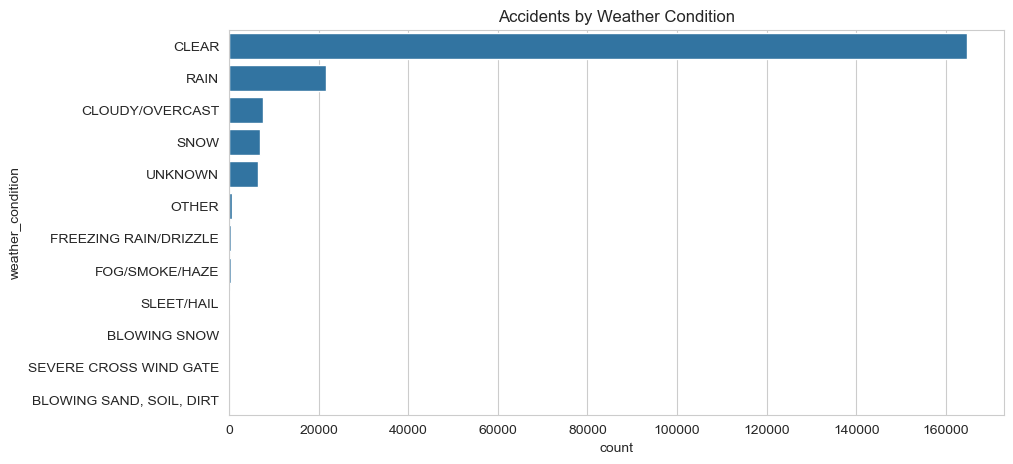

In [22]:
# Visualization 
plt.figure(figsize=(10,5))

sns.countplot(
    y="weather_condition",
    data=df,
    order=df["weather_condition"].value_counts().index
)

plt.title("Accidents by Weather Condition")

plt.show()

In [23]:
# Lighting Condition
df["lighting_condition"].value_counts()

lighting_condition
DAYLIGHT                  134083
DARKNESS, LIGHTED ROAD     53375
DARKNESS                    7436
DUSK                        6322
UNKNOWN                     4336
DAWN                        3723
Name: count, dtype: int64

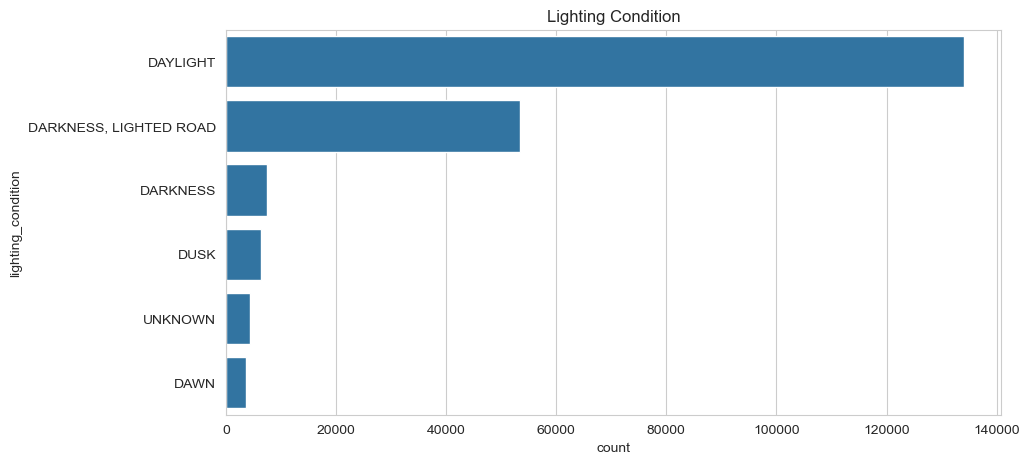

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="lighting_condition",
    data=df,
    order=df["lighting_condition"].value_counts().index
)

plt.title("Lighting Condition")

plt.show()

In [25]:
# Road Surface Condition
df["roadway_surface_cond"].value_counts()

roadway_surface_cond
DRY                155878
WET                 32906
UNKNOWN             12509
SNOW OR SLUSH        6201
ICE                  1303
OTHER                 438
SAND, MUD, DIRT        40
Name: count, dtype: int64

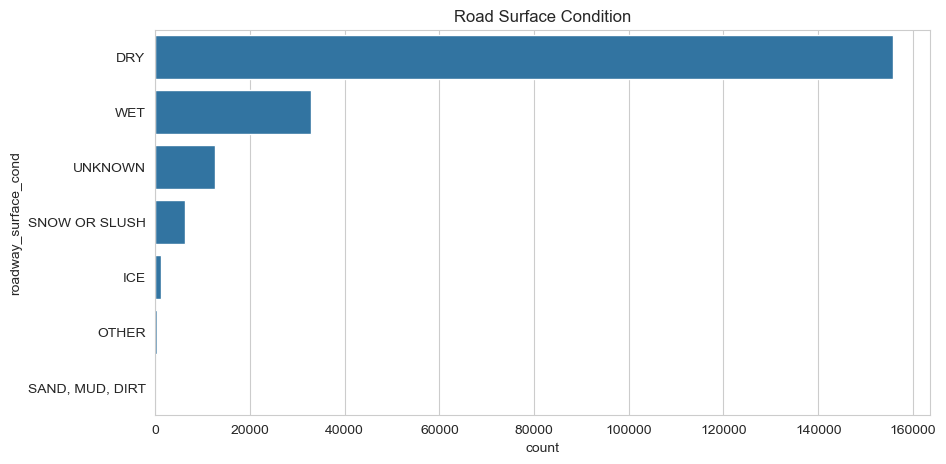

In [26]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="roadway_surface_cond",
    data=df,
    order=df["roadway_surface_cond"].value_counts().index
)

plt.title("Road Surface Condition")

plt.show()

In [27]:
# First Crash Type
df["first_crash_type"].value_counts()

first_crash_type
TURNING                         64150
ANGLE                           52243
REAR END                        42007
SIDESWIPE SAME DIRECTION        20114
PEDESTRIAN                       8995
PEDALCYCLIST                     5335
PARKED MOTOR VEHICLE             4892
FIXED OBJECT                     4742
SIDESWIPE OPPOSITE DIRECTION     1839
HEAD ON                          1790
REAR TO FRONT                    1157
REAR TO SIDE                      773
OTHER OBJECT                      759
OTHER NONCOLLISION                249
OVERTURNED                         96
ANIMAL                             77
REAR TO REAR                       49
TRAIN                               8
Name: count, dtype: int64

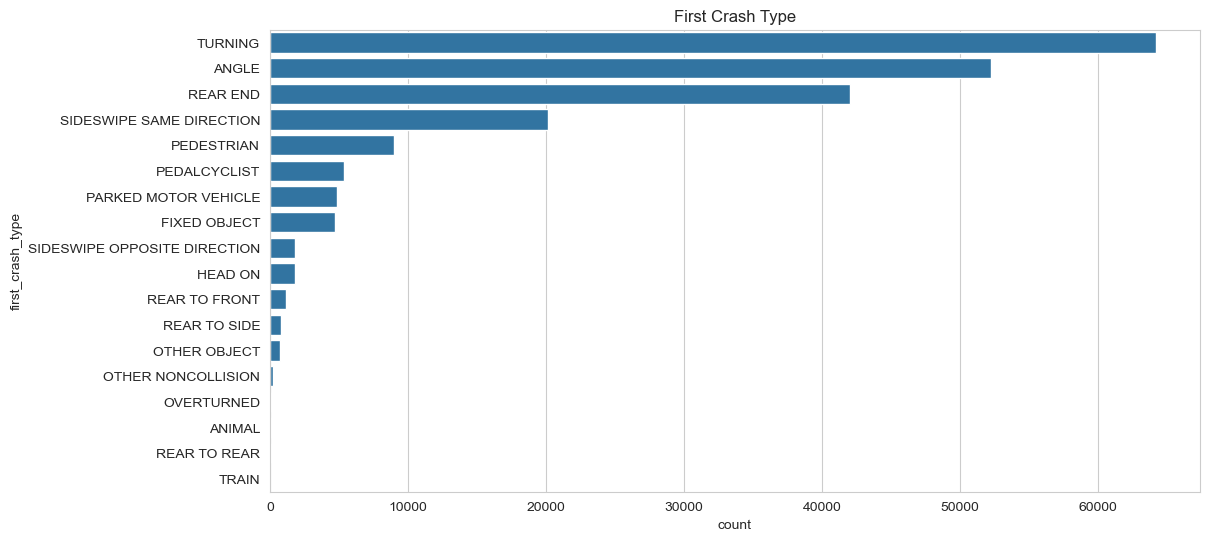

In [28]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="first_crash_type",
    data=df,
    order=df["first_crash_type"].value_counts().index
)

plt.title("First Crash Type")

plt.show()

In [29]:
# Primary Contributory Cause
df["prim_contributory_cause"].value_counts().head(15)

prim_contributory_cause
UNABLE TO DETERMINE                                                                 58310
FAILING TO YIELD RIGHT-OF-WAY                                                       42909
FOLLOWING TOO CLOSELY                                                               19074
DISREGARDING TRAFFIC SIGNALS                                                        14590
IMPROPER TURNING/NO SIGNAL                                                          12642
FAILING TO REDUCE SPEED TO AVOID CRASH                                              10675
IMPROPER OVERTAKING/PASSING                                                          8302
DISREGARDING STOP SIGN                                                               6746
IMPROPER LANE USAGE                                                                  6460
NOT APPLICABLE                                                                       5241
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE                                         

In [30]:
# Crash Hour Analysis
df["crash_hour"].value_counts().sort_index()

crash_hour
0      4487
1      3729
2      3080
3      2364
4      2104
5      2819
6      4771
7      9405
8     11379
9      9298
10     8989
11    10050
12    11725
13    11947
14    13346
15    15890
16    16020
17    16095
18    13429
19     9682
20     8219
21     7470
22     7035
23     5942
Name: count, dtype: int64

In [31]:
# Crash Month Analysis
df["crash_month"].value_counts().sort_index()

crash_month
1     16605
2     14617
3     15264
4     15095
5     17429
6     17848
7     17831
8     18346
9     19013
10    20088
11    18326
12    18813
Name: count, dtype: int64

In [32]:
# Crash Day of Week
df["crash_day_of_week"].value_counts().sort_index()

crash_day_of_week
1    25245
2    27930
3    30068
4    30089
5    30784
6    34453
7    30706
Name: count, dtype: int64

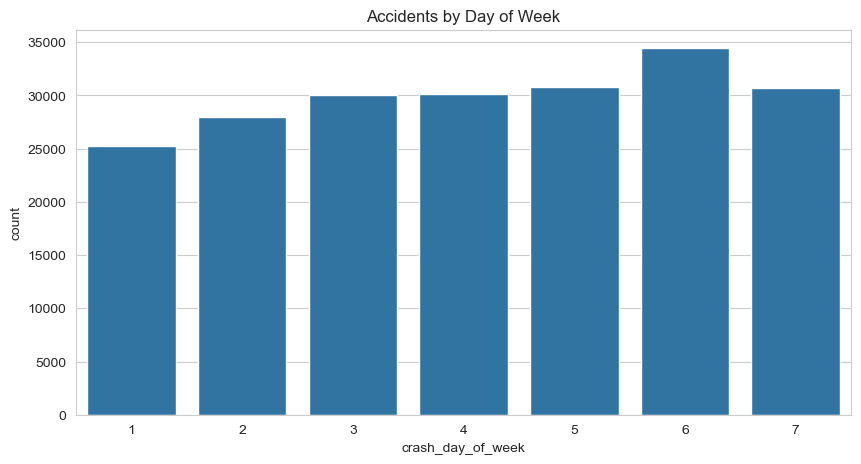

In [33]:
# visualization
plt.figure(figsize=(10,5))

sns.countplot(x="crash_day_of_week", data=df)

plt.title("Accidents by Day of Week")

plt.show()

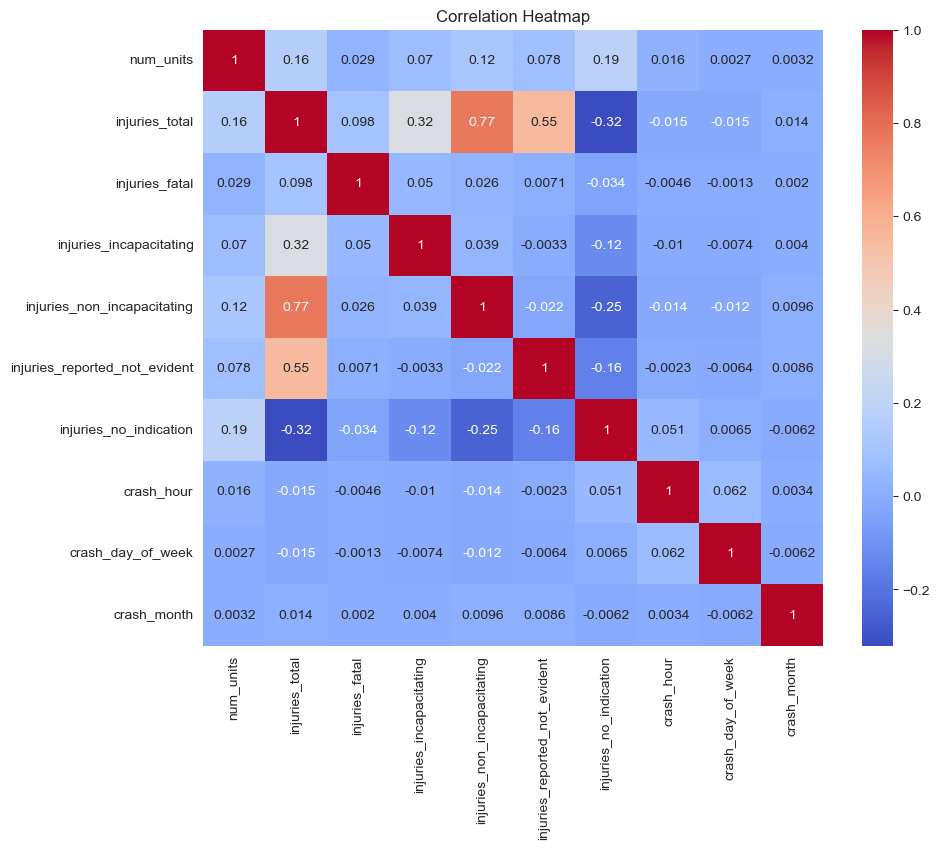

In [34]:
# Correlation Analysis
# Since we have numerical columns, we'll check their relationships.

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Phase 5: Data Preprocessing
What is Data Preprocessing?

"Data preprocessing is the process of converting raw data into a format suitable for machine learning. It includes selecting features, encoding categorical variables, scaling numerical features (if required), and splitting the dataset into training and testing sets."

In [35]:
# Select the Target Variable
# we need to decide what we want to predict,our target variable will be: crash_type 

In [36]:
# Separate Features (X) and Target (y)                        
''' I separated the independent variables (features) from the dependent variable (target). 
Here, crash_type is the target that the model will learn to predict. '''

# Features                                  
X = df.drop("crash_type", axis=1)

# Target
y = df["crash_type"]

In [37]:
X.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,intersection_related_i,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,Y,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,Y,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,Y,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,Y,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,Y,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [38]:
y.head()

0              NO INJURY / DRIVE AWAY
1              NO INJURY / DRIVE AWAY
2              NO INJURY / DRIVE AWAY
3    INJURY AND / OR TOW DUE TO CRASH
4              NO INJURY / DRIVE AWAY
Name: crash_type, dtype: object

In [39]:
# Encode the Target Variable
# Machine learning models cannot work directly with text labels. Let's first see the classes.
y.unique()

array(['NO INJURY / DRIVE AWAY', 'INJURY AND / OR TOW DUE TO CRASH'],
      dtype=object)

In [40]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [41]:
y

array([1, 1, 1, ..., 0, 0, 1])

In [42]:
# Encode the Feature Columns
# first checking  which columns are categorical.

X.select_dtypes(include="object").columns

Index(['crash_date', 'traffic_control_device', 'weather_condition',
       'lighting_condition', 'first_crash_type', 'trafficway_type',
       'alignment', 'roadway_surface_cond', 'road_defect',
       'intersection_related_i', 'damage', 'prim_contributory_cause',
       'most_severe_injury'],
      dtype='object')

In [43]:
X.nunique().sort_values(ascending=False)

crash_date                       189087
prim_contributory_cause              40
injuries_no_indication               39
crash_hour                           24
trafficway_type                      20
traffic_control_device               19
injuries_non_incapacitating          19
injuries_total                       19
first_crash_type                     18
injuries_reported_not_evident        13
weather_condition                    12
crash_month                          12
num_units                            11
injuries_incapacitating               8
road_defect                           7
roadway_surface_cond                  7
crash_day_of_week                     7
lighting_condition                    6
alignment                             6
most_severe_injury                    5
injuries_fatal                        4
damage                                3
intersection_related_i                2
dtype: int64

In [44]:
 # removing crash_date column 
X = X.drop("crash_date", axis=1)

X.columns

In [45]:
"crash_date" in X.columns

False

In [46]:
# Now performing one-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [47]:
X.shape  

(209275, 143)

out Target: crash_type

Then we remove only the columns that leak the answer:

most_severe_injury
injuries_total
injuries_fatal
injuries_incapacitating
injuries_non_incapacitating
injuries_reported_not_evident
injuries_no_indication

This is not because they are bad features, but because they are known only after the accident outcome. If your goal is to predict whether a crash will involve injury, you wouldn't have these values at prediction time.

In [48]:
X = df.drop("crash_type", axis=1)
y = df["crash_type"]

In [49]:
X = X.drop("crash_date", axis=1)

In [50]:
# Remove leakage columns
X = X.drop(columns=[
    "most_severe_injury",
    "injuries_total",
    "injuries_fatal",
    "injuries_incapacitating",
    "injuries_non_incapacitating",
    "injuries_reported_not_evident",
    "injuries_no_indication"
])

In [51]:
X = pd.get_dummies(X, drop_first=True)

In [52]:
X.head()

,num_units,crash_hour,crash_day_of_week,crash_month,traffic_control_device_DELINEATORS,traffic_control_device_FLASHING CONTROL SIGNAL,traffic_control_device_LANE USE MARKING,traffic_control_device_NO CONTROLS,traffic_control_device_NO PASSING,traffic_control_device_OTHER,...,prim_contributory_cause_PHYSICAL CONDITION OF DRIVER,prim_contributory_cause_RELATED TO BUS STOP,prim_contributory_cause_ROAD CONSTRUCTION/MAINTENANCE,prim_contributory_cause_ROAD ENGINEERING/SURFACE/MARKING DEFECTS,prim_contributory_cause_TEXTING,prim_contributory_cause_TURNING RIGHT ON RED,prim_contributory_cause_UNABLE TO DETERMINE,prim_contributory_cause_UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),"prim_contributory_cause_VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",prim_contributory_cause_WEATHER
0,2,13,7,7,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,2,0,1,8,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,10,5,12,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2,19,4,8,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,2,14,7,8,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [53]:
# Split the data again

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Phase 6: Model Building

We'll build three models:

Logistic Regression (Baseline)
Decision Tree
Random Forest

# Model 1: Logistic Regression

In [54]:
# Import
from sklearn.linear_model import LogisticRegression

In [55]:
# Creating the model
lr = LogisticRegression(max_iter=1000)

In [56]:
# Training  Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [57]:
# Predict
y_pred_lr = lr.predict(X_test)

In [58]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_lr)

0.741440688089834

In [59]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_lr)

array([[12913,  5471],
       [ 5351, 18120]])

In [60]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

                                  precision    recall  f1-score   support

INJURY AND / OR TOW DUE TO CRASH       0.71      0.70      0.70     18384
          NO INJURY / DRIVE AWAY       0.77      0.77      0.77     23471

                        accuracy                           0.74     41855
                       macro avg       0.74      0.74      0.74     41855
                    weighted avg       0.74      0.74      0.74     41855



In [61]:
# Since we have 133 features, Logistic Regression may show a convergence warning on some systems.You can make it more robust by specifying the solver:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

# Model 2: Decision Tree Classifier

A Decision Tree makes predictions by asking a sequence of yes/no questions about the features until it reaches a final prediction.

In [62]:
# import 
from sklearn.tree import DecisionTreeClassifier

In [63]:
# Creating the Model
dt = DecisionTreeClassifier(random_state=42)

In [64]:
# Training the Model
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [65]:
# Making Predictions
y_pred_dt = dt.predict(X_test)

In [66]:
# Checking Accuracy
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6508183012782225


In [67]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

[[11495  6889]
 [ 7726 15745]]


In [68]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

                                  precision    recall  f1-score   support

INJURY AND / OR TOW DUE TO CRASH       0.60      0.63      0.61     18384
          NO INJURY / DRIVE AWAY       0.70      0.67      0.68     23471

                        accuracy                           0.65     41855
                       macro avg       0.65      0.65      0.65     41855
                    weighted avg       0.65      0.65      0.65     41855



# Model 3 : Random Forest 

In [69]:
# Import
from sklearn.ensemble import RandomForestClassifier

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [71]:
# training the model 
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [72]:
# prediction 
y_pred_rf = rf.predict(X_test)

In [73]:
# Accuracy 
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7132481185043603


In [74]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))

[[12170  6214]
 [ 5788 17683]]


In [75]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

                                  precision    recall  f1-score   support

INJURY AND / OR TOW DUE TO CRASH       0.68      0.66      0.67     18384
          NO INJURY / DRIVE AWAY       0.74      0.75      0.75     23471

                        accuracy                           0.71     41855
                       macro avg       0.71      0.71      0.71     41855
                    weighted avg       0.71      0.71      0.71     41855



# Phase 7: Hyperparameter Tuning

We should try to improve the Random Forest before making the final decision.

In [76]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

In [77]:
# Create Parameter Grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [78]:
# Create GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [50],
    "max_depth": [10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

In [79]:
# Train GridSearch
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10], 'n_estimators': [50]},
             scoring='accuracy', verbose=2)

In [80]:
# Best Parameters
print(grid_search.best_params_)

{'max_depth': 10, 'n_estimators': 50}


In [81]:
# Best Score
print(grid_search.best_score_)

0.7343686499203069


In [82]:
# Use the Best Model
best_rf = grid_search.best_estimator_

In [83]:
# Predict
y_pred_best = best_rf.predict(X_test)

In [84]:
# Evaluate
from sklearn.metrics import accuracy_score

print("Optimized Random Forest Accuracy:", accuracy_score(y_test, y_pred_best))

Optimized Random Forest Accuracy: 0.7331501612710548


In [85]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

[[12990  5394]
 [ 5775 17696]]
                                  precision    recall  f1-score   support

INJURY AND / OR TOW DUE TO CRASH       0.69      0.71      0.70     18384
          NO INJURY / DRIVE AWAY       0.77      0.75      0.76     23471

                        accuracy                           0.73     41855
                       macro avg       0.73      0.73      0.73     41855
                    weighted avg       0.73      0.73      0.73     41855



# Phase 8: Feature Importance

In [86]:
# Feature Importance

feature_importance = rf.feature_importances_

In [87]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
})

In [88]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [89]:
importance_df.head(10)

,Feature,Importance
1,crash_hour,0.169132
3,crash_month,0.148335
2,crash_day_of_week,0.112523
93,"damage_OVER $1,500",0.039178
46,first_crash_type_PEDESTRIAN,0.035387
92,"damage_$501 - $1,500",0.033431
52,first_crash_type_SIDESWIPE SAME DIRECTION,0.028624
0,num_units,0.027343
47,first_crash_type_REAR END,0.024880
54,first_crash_type_TURNING,0.016222


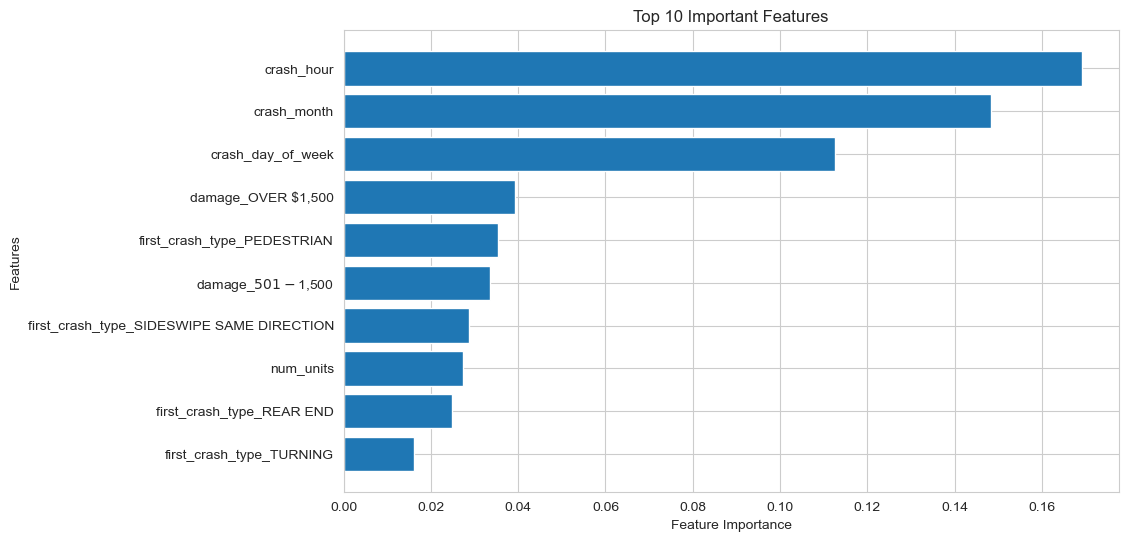

In [90]:
# Visualization :
import matplotlib.pyplot as plt

top10 = importance_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features")
plt.show()

# Phase 9: Cross Validation.

In [91]:
# Import Cross Validation
from sklearn.model_selection import cross_val_score

In [92]:
# Perform Cross Validation
# Since Logistic Regression gave the highest accuracy (74.14%), we'll evaluate that model.
'''
Explanation:

lr → Logistic Regression model
X → Features
y → Target
cv=5 → 5-fold cross validation
scoring="accuracy" → Evaluate using accuracy
n_jobs=-1 → Use all CPU cores
'''
scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [93]:
# Displaying Scores
print(scores)

[0.7431848  0.73757018 0.74227691 0.74277864 0.7405089 ]


In [94]:
# Average Accuracy
print("Average Accuracy:", scores.mean())

Average Accuracy: 0.7412638872297216


In [95]:
# Standard Deviation
print("Standard Deviation:", scores.std())

Standard Deviation: 0.00206029473489029


# phase 10 : Save the Best Model

Since Logistic Regression gave the best performance (74.14% accuracy), we'll save it for deployment.

In [101]:
# Training the model again 
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [102]:
# verifyng whether its trained 
print(hasattr(lr, "coef_"))

True


In [103]:
# Saving the trained model
import joblib

joblib.dump(lr, "traffic_accident_model.pkl")

['traffic_accident_model.pkl']

In [104]:
# Loading the model
loaded_model = joblib.load("traffic_accident_model.pkl")

In [105]:
# Verifying 
loaded_model.predict(X_test[:5])

array(['NO INJURY / DRIVE AWAY', 'NO INJURY / DRIVE AWAY',
       'NO INJURY / DRIVE AWAY', 'INJURY AND / OR TOW DUE TO CRASH',
       'NO INJURY / DRIVE AWAY'], dtype=object)